# 03 Anomaly Analysis

Detect unusual weather records using z-scores and Isolation Forest, then save anomaly-tagged and anomaly-free outputs.


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "GlobalWeatherRepository.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.preprocessing import (
    add_isolation_forest_anomalies,
    compute_zscore_outliers,
    get_numeric_columns,
    load_processed_data,
    remove_anomalies,
    save_processed_data,
)
from src.visualize import (
    plot_kde_comparison,
    plot_scatter_with_hue,
    plot_top_categories,
    save_figure,
)


In [3]:
clean_data_path = PROCESSED_DIR / "clean_weather_data.csv"
df = load_processed_data(clean_data_path)
numeric_columns = get_numeric_columns(df)

df["zscore_outlier"] = compute_zscore_outliers(df, numeric_columns)
anomaly_df = add_isolation_forest_anomalies(df, numeric_columns, contamination=0.05)
anomaly_df["zscore_outlier"] = df["zscore_outlier"]

print(anomaly_df[["zscore_outlier", "anomaly"]].value_counts())
display(anomaly_df.head())


zscore_outlier  anomaly
False            1         115860
True             1          14682
                -1           6339
False           -1            532
Name: count, dtype: int64


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,zscore_outlier,anomaly,anomaly_score
0,United States of America,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,2024-05-16 01:45:00,16.1,61.0,Clear,...,1,05:26 AM,08:31 PM,01:36 PM,02:52 AM,Waxing Gibbous,55,False,1,0.090218
1,Honduras,Tegucigalpa,14.10,-87.22,America/Tegucigalpa,1715849100,2024-05-16 02:45:00,23.0,73.4,Partly cloudy,...,2,05:22 AM,06:09 PM,12:52 PM,12:55 AM,Waxing Gibbous,55,False,1,0.106103
2,El Salvador,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,2024-05-16 02:45:00,26.0,78.8,Moderate or heavy rain with thunder,...,2,05:30 AM,06:16 PM,01:00 PM,01:02 AM,Waxing Gibbous,55,False,1,0.082177
3,Guatemala,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,2024-05-16 02:45:00,20.0,68.0,Mist,...,10,05:34 AM,06:23 PM,01:05 PM,01:09 AM,Waxing Gibbous,55,True,-1,-0.032102
4,Belize,Belmopan,17.25,-88.77,America/Belize,1715849100,2024-05-16 02:45:00,26.0,78.9,Overcast,...,1,05:23 AM,06:20 PM,12:56 PM,01:04 AM,Waxing Gibbous,55,False,1,0.122731


<Figure size 1600x600 with 0 Axes>

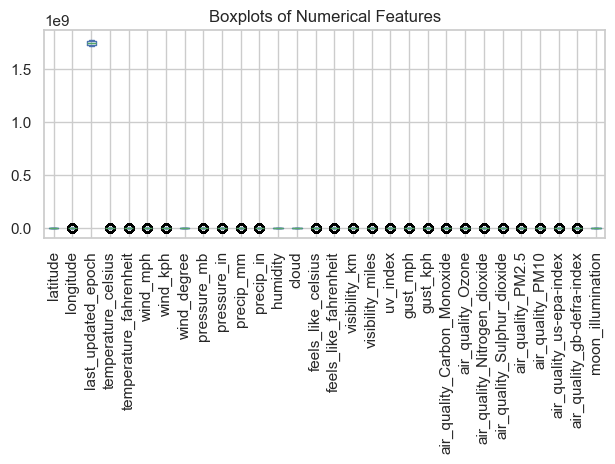

In [4]:
plt.figure(figsize=(16, 6))
anomaly_df[numeric_columns].plot(kind="box", rot=90)
plt.title("Boxplots of Numerical Features")
plt.tight_layout()
plt.show()


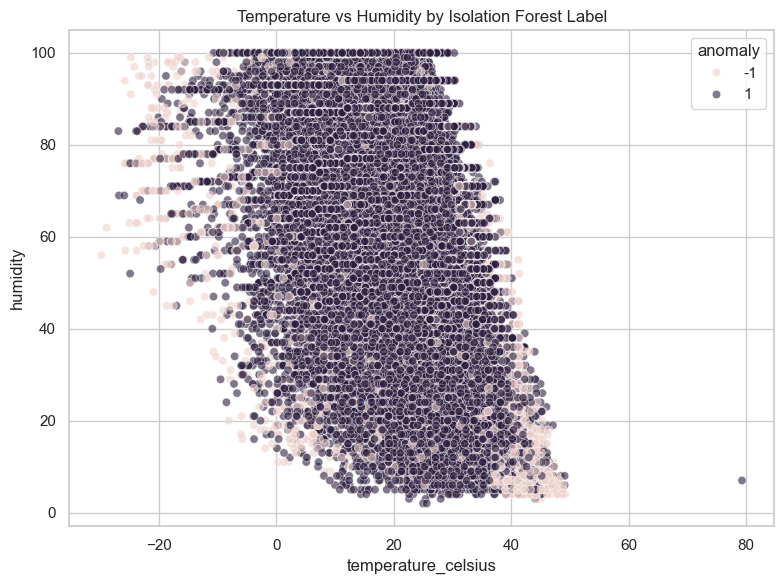

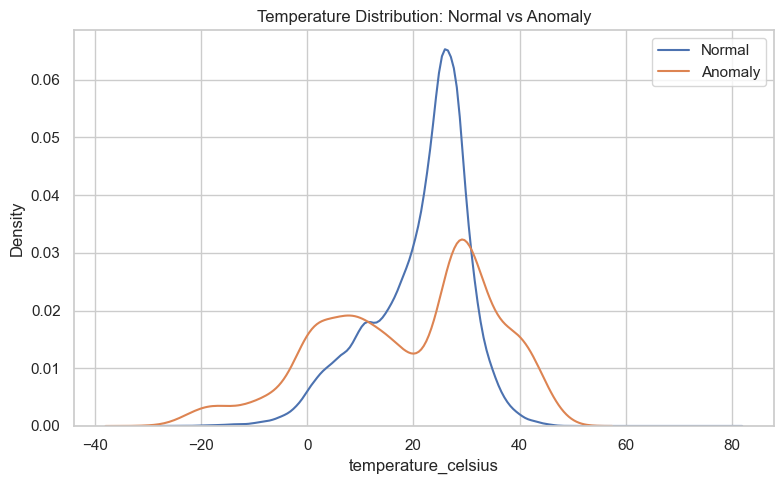

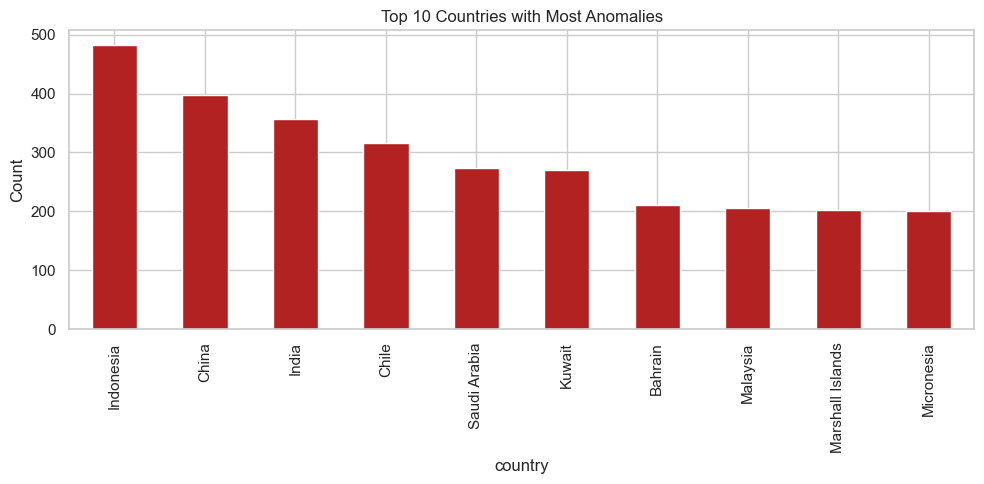

In [5]:
fig_scatter = plot_scatter_with_hue(
    anomaly_df,
    x="temperature_celsius",
    y="humidity",
    hue="anomaly",
    title="Temperature vs Humidity by Isolation Forest Label",
)
display(fig_scatter)
save_figure(fig_scatter, FIGURES_DIR / "anomaly_temperature_humidity.png")
plt.close(fig_scatter)

fig_temp = plot_kde_comparison(
    anomaly_df,
    value_column="temperature_celsius",
    group_column="anomaly",
    label_map={1: "Normal", -1: "Anomaly"},
    title="Temperature Distribution: Normal vs Anomaly",
)
display(fig_temp)
plt.close(fig_temp)

fig_country = plot_top_categories(
    anomaly_df.loc[anomaly_df["anomaly"] == -1, "country"],
    top_n=10,
    title="Top 10 Countries with Most Anomalies",
    color="firebrick",
)
display(fig_country)
save_figure(fig_country, FIGURES_DIR / "anomaly_top_countries.png")
plt.close(fig_country)


In [6]:
anomaly_output = PROCESSED_DIR / "anomaly_scored_weather_data.csv"
normal_output = PROCESSED_DIR / "weather_without_anomalies.csv"

normal_df = remove_anomalies(anomaly_df)
save_processed_data(anomaly_df, anomaly_output)
save_processed_data(normal_df, normal_output)

print(f"Saved anomaly-scored data to: {anomaly_output}")
print(f"Saved anomaly-free data to: {normal_output}")
print(f"Anomaly-free shape: {normal_df.shape}")


Saved anomaly-scored data to: D:\Projects 2025\weather-forecasting-eda-ml\data\processed\anomaly_scored_weather_data.csv
Saved anomaly-free data to: D:\Projects 2025\weather-forecasting-eda-ml\data\processed\weather_without_anomalies.csv
Anomaly-free shape: (130542, 44)
